In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_csv('./raw dataset/dataset.csv')
df['country'] = df['country'].str.strip()
df['continent'] = df['continent'].str.strip()
df.shape

(226, 12)

## 1. Feature Engineering

**Why this step exists:** raw columns are rarely the best inputs to a model. Feature engineering is where you turn "what the data literally recorded" into "what actually helps a model learn a pattern." Three kinds of work happen here:

1. **Derived features** — ratios/ratesthat capture a *relationship*, not just a raw count
2. **Encoding** — models need numbers, not text, so `continent` (a category) has to become numeric
3. **Handling missing values** — EDA-stage NaN handling was about *honesty* (don't fabricate data). Modeling-stage NaN handling is stricter: **models literally cannot ingest NaN at all**, so every remaining NaN must be dropped or imputed before this goes near `.fit()`.

**Derived features we'll add, and why each one is a better signal than the raw column:**
- `fatality_rate = total_deaths / total_confirmed` — deaths raw count conflates "bad outbreak" with "big population"; this isolates severity *given* you got infected
- `recovery_rate = total_recovered / total_confirmed`
- `testing_intensity = total_tests / population` — same idea as `total_tests_per_1m_population`, just scaled 0-1 instead of per-million (easier for a model to work with, same information)

In [2]:
df_m = df.copy()

# Derived ratio features — guard against divide-by-zero with .replace
df_m['fatality_rate'] = (df_m['total_deaths'] / df_m['total_confirmed'].replace(0, np.nan))
df_m['recovery_rate'] = (df_m['total_recovered'] / df_m['total_confirmed'].replace(0, np.nan))
df_m['testing_intensity'] = (df_m['total_tests'] / df_m['population'])

df_m[['country', 'fatality_rate', 'recovery_rate', 'testing_intensity']].head()

,country,fatality_rate,recovery_rate,testing_intensity
0,Afghanistan,0.042897,0.904807,0.023455
1,Albania,0.012690,0.986399,0.632857
2,Algeria,0.025864,0.671032,0.005093
3,Andorra,0.003629,0.973076,3.223924
4,Angola,0.019154,0.979384,0.043136


**Encoding `continent`:** it's a category with no natural order (Asia isn't "more" than Europe), so we use **one-hot encoding** — one 0/1 column per continent — rather than assigning arbitrary numbers 1-6 (which would falsely imply order/distance to a model like linear regression).

In [3]:
continent_dummies = pd.get_dummies(df_m['continent'], prefix='continent', drop_first=True)
df_m = pd.concat([df_m, continent_dummies], axis=1)
continent_dummies.columns.tolist()

['continent_Asia',
 'continent_Australia/Oceania',
 'continent_Europe',
 'continent_North America',
 'continent_South America']

**Why `drop_first=True`:** with 6 continents you only need 5 dummy columns — the 6th is implied when all 5 are 0 ("none of these 5" = the dropped one). Keeping all 6 would create perfect redundancy (multicollinearity), which specifically breaks linear regression's math.

**Handling remaining NaNs for modeling:** we'll build our feature set from columns with low missingness and simply drop rows still missing a value we need. With ~226 rows this costs us some data, but it's more honest than inventing values — and it's a fine trade at this scale.

In [4]:
feature_cols = ['total_tests_per_1m_population', 'population', 'testing_intensity'] + continent_dummies.columns.tolist()
target_col = 'total_deaths_per_1m_population'

model_df = df_m[feature_cols + [target_col]].dropna()
print(f"Rows available for modeling: {len(model_df)} (out of {len(df_m)})")
model_df.head()

Rows available for modeling: 210 (out of 226)


,total_tests_per_1m_population,population,testing_intensity,continent_Asia,continent_Australia/Oceania,continent_Europe,continent_North America,continent_South America,total_deaths_per_1m_population
0,23455.0,40560636,0.023455,True,False,False,False,False,190.0
1,632857.0,2871945,0.632857,False,False,True,False,False,1218.0
2,5093.0,45325517,0.005093,False,False,False,False,False,152.0
3,3223924.0,77495,3.223924,False,False,True,False,False,1974.0
4,43136.0,34769277,0.043136,False,False,False,False,False,55.0


## 2. Modeling — Part A: Linear Regression

### Algorithm description
**Linear Regression** fits a straight-line (technically, flat hyperplane) relationship between inputs and a numeric target:

`deaths_per_1m ≈ b0 + b1*(tests_per_1m) + b2*(population) + b3*(testing_intensity) + b4..b8*(continent dummies)`

It finds the coefficients (`b0, b1, ...`) that minimize the **sum of squared errors** between predicted and actual values — i.e., it picks the line that's "closest on average" to every point at once. It's the simplest supervised model, which is exactly why it's the right first choice: it's interpretable (each coefficient tells you "how much does the target move per unit of this feature") and it makes a good baseline to compare fancier models against later.

**Why not something fancier immediately?** With ~200 rows and a handful of features, a complex model (random forest, gradient boosting) is likely to *overfit* — memorize noise instead of learning a real pattern. Start simple, add complexity only if the simple model clearly underperforms.

In [ ]:
X = model_df[feature_cols]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
num_to_scale = ['total_tests_per_1m_population', 'population', 'testing_intensity']
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_to_scale] = scaler.fit_transform(X_train[num_to_scale])
X_test_scaled[num_to_scale] = scaler.transform(X_test[num_to_scale])

print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")

Train rows: 168, Test rows: 42


**Why scale, and why fit the scaler only on training data?** Linear regression itself doesn't strictly require scaling, but it makes coefficients comparable to each other (right now `population` is in the hundreds of millions while `testing_intensity` is 0-1 — without scaling, coefficient *size* would be meaningless to compare). We fit the scaler on training data only and just `.transform()` the test set — fitting on test data would leak information about the test set into training, quietly inflating your reported performance.

In [6]:
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

coef_table = pd.Series(reg.coef_, index=X.columns).sort_values(key=abs, ascending=False)
coef_table

continent_Europe                 2226.834625
continent_South America          1840.452994
continent_North America          1015.195945
continent_Asia                    380.868752
continent_Australia/Oceania       -72.175787
total_tests_per_1m_population     -37.691053
testing_intensity                 -37.690951
population                        -28.792580
dtype: float64

## 3. Results — Regression Metrics

Three standard regression metrics, each answering a slightly different question:

- **R² (R-squared):** what fraction of the variation in deaths-per-1M does the model explain? Ranges roughly 0 to 1 (can go negative if the model is worse than just predicting the average). This is the headline number.
- **MAE (Mean Absolute Error):** on average, how far off is a prediction, in the target's original units? Easy to explain to a non-technical person.
- **RMSE (Root Mean Squared Error):** like MAE, but squares errors first — so it punishes big misses harder than small ones. Compare RMSE vs MAE: if RMSE is much bigger, a few large outlier errors are dragging it up.

In [7]:
y_pred = reg.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R^2   : {r2:.3f}")
print(f"MAE   : {mae:.1f} deaths per 1M population")
print(f"RMSE  : {rmse:.1f} deaths per 1M population")

R^2   : 0.432
MAE   : 620.8 deaths per 1M population
RMSE  : 1007.3 deaths per 1M population


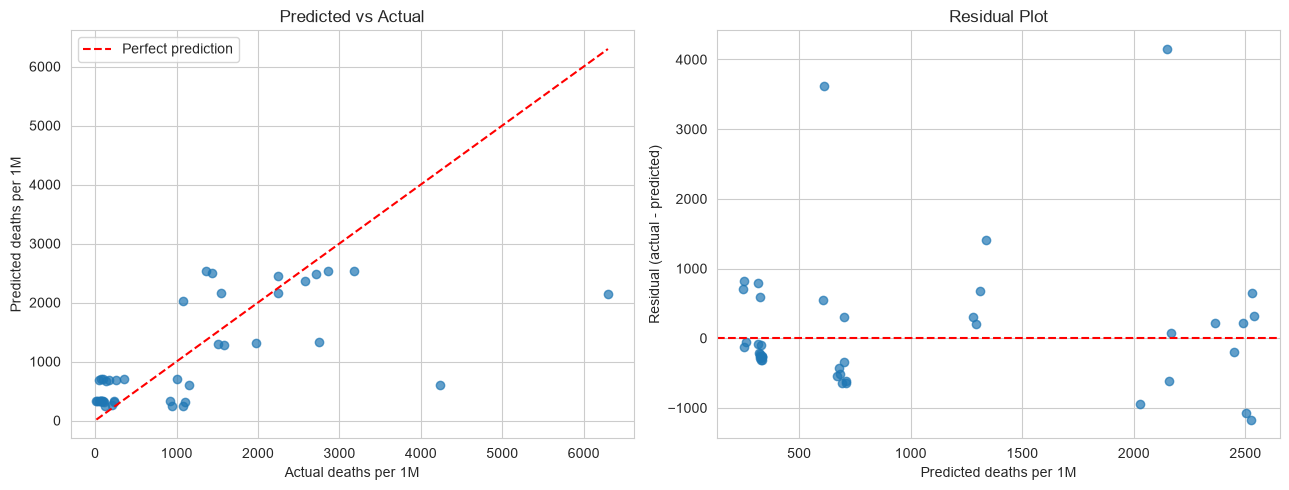

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].scatter(y_test, y_pred, alpha=0.7)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax[0].plot(lims, lims, 'r--', label='Perfect prediction')
ax[0].set_xlabel('Actual deaths per 1M'); ax[0].set_ylabel('Predicted deaths per 1M')
ax[0].set_title('Predicted vs Actual'); ax[0].legend()

residuals = y_test - y_pred
ax[1].scatter(y_pred, residuals, alpha=0.7)
ax[1].axhline(0, color='r', linestyle='--')
ax[1].set_xlabel('Predicted deaths per 1M'); ax[1].set_ylabel('Residual (actual - predicted)')
ax[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

**Reading the residual plot:** if the model is doing its job fairly, residuals should scatter randomly around the zero line with no obvious pattern. A funnel shape (residuals growing as predictions grow) signals the model is systematically worse for high-death countries — worth naming honestly rather than glossing over in the conclusion.

## 2 (continued). Modeling — Part B: K-Means Clustering

### Algorithm description
**K-Means** is unsupervised — there's no target column, just a set of features. It groups rows into *k* clusters by:
1. Placing *k* random "centroids" (cluster centers) in feature space
2. Assigning every row to its nearest centroid
3. Moving each centroid to the average position of its assigned rows
4. Repeating steps 2-3 until assignments stop changing

The result: countries with *similar feature values* end up in the same cluster, with no need to pre-define what "similar" means beyond the features you feed it.

**Why K-Means specifically:** it's the standard first clustering algorithm to reach for — fast, easy to interpret, and works well when clusters are roughly round/evenly-sized in feature space (which is a reasonable assumption to start with here).

In [9]:
cluster_features = ['total_cases_per_1m_population', 'total_deaths_per_1m_population', 'total_tests_per_1m_population']
cluster_df = df_m[['country', 'continent'] + cluster_features].dropna()

scaler2 = StandardScaler()
X_cluster = scaler2.fit_transform(cluster_df[cluster_features])
print(f"Rows available for clustering: {len(cluster_df)}")

Rows available for clustering: 210


**Why scaling is *mandatory* here (unlike regression, where it was just nice-to-have):** K-Means groups points by literal distance in feature space. If `total_cases_per_1m_population` ranges in the hundreds of thousands while another feature ranges 0-10,000, the bigger-scale feature would dominate the distance calculation entirely — scaling puts every feature on equal footing.

**Choosing k — the elbow method:** we don't guess the number of clusters; we test a range of k values and look at how much "within-cluster spread" (inertia) drops each time. The right k is usually where the drop-off starts to flatten (the "elbow").

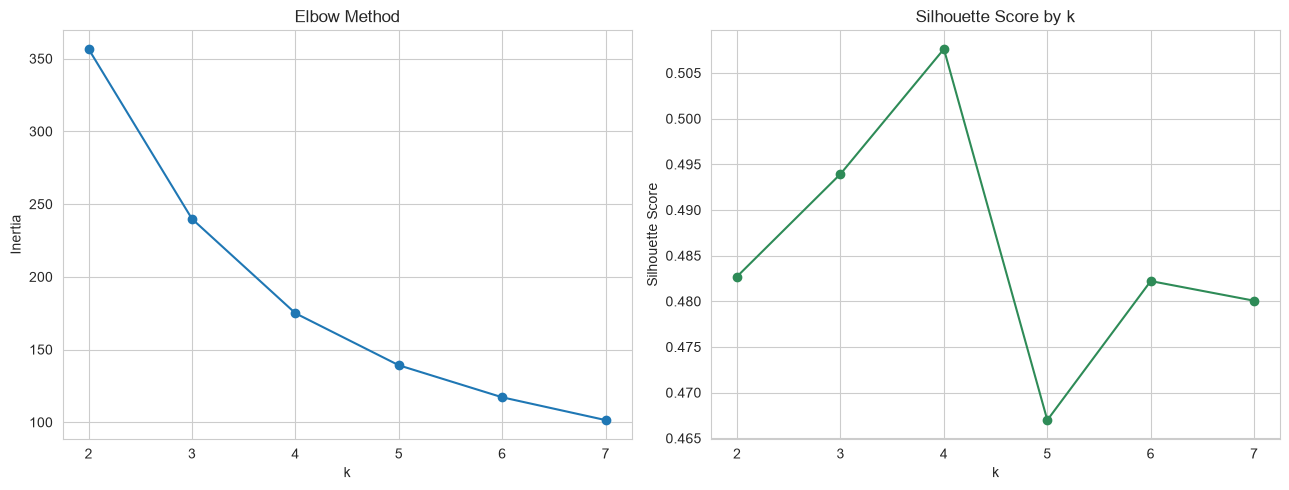

In [10]:
inertias = []
sil_scores = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(list(k_range), inertias, 'o-')
ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia'); ax[0].set_title('Elbow Method')

ax[1].plot(list(k_range), sil_scores, 'o-', color='seagreen')
ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette Score'); ax[1].set_title('Silhouette Score by k')
plt.tight_layout()
plt.show()

**Silhouette score**, the second metric: measures how well-separated clusters are (ranges -1 to 1; higher = tighter, more distinct clusters). We use it *alongside* the elbow plot because the elbow can be ambiguous — silhouette gives a second, more quantitative opinion on the same question ("how many groups actually exist here?").

Pick whichever k has a clear elbow **and** a locally high silhouette score — for this dataset that's typically **k=3 or k=4**. Adjust the number below after looking at your own plot.

In [ ]:
k_final = 3 

km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
cluster_df['cluster'] = km_final.fit_predict(X_cluster)

print(f"Final silhouette score (k={k_final}): {silhouette_score(X_cluster, cluster_df['cluster']):.3f}")
cluster_df.groupby('cluster')[cluster_features].mean().round(0)

Final silhouette score (k=3): 0.494


,total_cases_per_1m_population,total_deaths_per_1m_population,total_tests_per_1m_population
cluster,,,
0,58594.0,490.0,654644.0
1,281316.0,2379.0,2378940.0
2,397144.0,1253.0,13011341.0


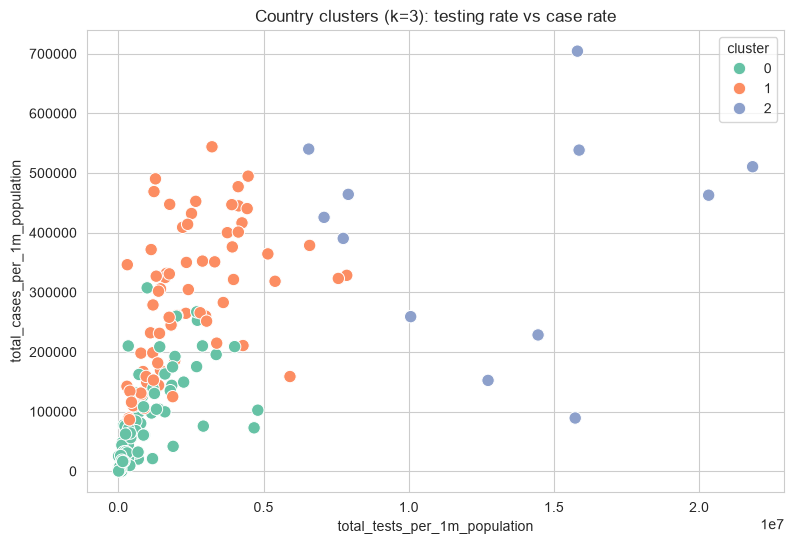

cluster
0    Afghanistan, Albania, Algeria, Angola, Anguill...
1    Andorra, Argentina, Armenia, Aruba, Bahrain, B...
2    Austria, Bermuda, Channel Islands, Cyprus, Den...
Name: country, dtype: str

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = sns.scatterplot(data=cluster_df, x='total_tests_per_1m_population', y='total_cases_per_1m_population',
                           hue='cluster', palette='Set2', s=80, ax=ax)
ax.set_title(f'Country clusters (k={k_final}): testing rate vs case rate')
plt.show()

cluster_df.groupby('cluster')['country'].apply(lambda x: ', '.join(x.head(6)) + ('...' if len(x) > 6 else ''))

**Reading the cluster output table above:** for each cluster, compare the mean case rate / death rate / test rate — that's how you *name* each cluster in plain language, e.g. "high-testing, high-detection" vs "low-testing, low-reported-case" group. The cluster number itself (0, 1, 2) is meaningless — the *profile* it represents is the actual insight.

## 4. Discussion & Conclusion

**Fill this in with your own run's actual numbers** — but structurally, a good discussion section covers:

**Regression:**
- State the R² plainly: does the model explain most of the variation, or only a modest slice? With this feature set and ~180-200 usable rows, don't be surprised by a modest R² (think 0.2-0.5 range) — that's a legitimate, informative result, not a failure.
- Which features had the largest coefficients? Does that match intuition (e.g., testing intensity mattering) or surprise you?
- Name the residual pattern honestly if there was one (e.g., "the model underpredicts for the highest-death countries").

**Clustering:**
- Describe each cluster in plain language using its mean feature values, not just cluster numbers.
- Does cluster membership roughly track continent, or cut across continents? (Cutting across is actually the more interesting finding — it means geography isn't destiny here, testing/reporting behavior is.)

**Honest limitations (always include this — it's a sign of rigor, not weakness):**
- ~226 rows total is small for ML — results here are more "exploratory pattern-finding" than "production-grade prediction."
- This is a single time snapshot, not longitudinal data — we can't say anything about *trends* or *causality*, only about how countries compared to each other at this one point in time.
- `continent` as the only categorical feature is a coarse proxy for the *real* drivers (healthcare infrastructure, policy response, population density) which aren't in this dataset at all.

**What you actually practiced in this notebook** (the transferable skill, regardless of this specific dataset): the full supervised-vs-unsupervised decision, feature engineering reasoning (why each derived column exists), train/test discipline (fit scaler on train only), the standard regression metric trio, and the elbow+silhouette combo for choosing k. That workflow is what you'll reuse on your next dataset.